# Condition Number Analysis: Power Law Investigation

This notebook investigates the relationship between the condition number of the true covariance matrix and the condition numbers of sample covariance matrices as a function of sample size.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
sys.path.append('../')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [4]:
from src.datasets import build_true_matrix, simulate_from_covariance_mean

## 1. Generate True Covariance Matrix

In [5]:
# Set random seed for reproducibility
np.random.seed(0)

# Parameters for the true covariance matrix
number_blocks = 5
block_size = 10
block_correlation = 0.5

# Build the true covariance matrix
true_mu, true_covariance = build_true_matrix(
    number_blocks=number_blocks,
    block_size=block_size,
    block_correlation=block_correlation
)

print(f"Covariance matrix shape: {true_covariance.shape}")
print(f"Mean vector shape: {true_mu.shape}")

Covariance matrix shape: (50, 50)
Mean vector shape: (50, 1)


## 2. Compute Condition Number of True Covariance (cond_0)

In [6]:
# Compute the condition number of the true covariance matrix
cond_0 = np.linalg.cond(true_covariance)
print(f"Condition number of true covariance (cond_0): {cond_0:.4f}")

Condition number of true covariance (cond_0): 91.0112


## 3. Generate Samples and Compute Condition Numbers

In [7]:
# Define sample sizes to test
# We'll use a range from 100 to 10000 with appropriate steps
sample_sizes = list(range(100, 1000, 100)) + list(range(1000, 10001, 500))

# Number of replications for each sample size
num_replications = 200

print(f"Testing {len(sample_sizes)} sample sizes: {sample_sizes}")
print(f"Running {num_replications} replications for each sample size")
print(f"Total experiments: {len(sample_sizes) * num_replications}")

Testing 28 sample sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
Running 200 replications for each sample size
Total experiments: 5600


In [8]:
# Storage for results
results = {
    'sample_size': [],
    'cond_n_median': [],
    'cond_n_q25': [],
    'cond_n_q75': [],
    'cond_n_mean': [],
    'cond_n_std': [],
    'ratio_median': [],  # This will be used for power law analysis
    'ratio_q25': [],
    'ratio_q75': [],
    'ratio_mean': [],
    'ratio_std': []
}

# Run the experiment with replications
print("Generating samples and computing condition numbers...")
print("This may take a few minutes...\n")

for n in tqdm(sample_sizes, desc="Sample sizes"):
    # Storage for replications
    cond_n_replications = []
    ratio_replications = []
    
    # Run multiple replications for this sample size
    for r in range(num_replications):
        # Generate n samples from the true covariance
        data, sample_mu, sample_covariance = simulate_from_covariance_mean(
            true_mu=true_mu,
            true_covariance=true_covariance,
            number_of_observations=n
        )
        
        # Compute condition number of sample covariance
        cond_n = np.linalg.cond(sample_covariance)
        
        # Compute ratio
        ratio = cond_n / cond_0
        
        # Store replication results
        cond_n_replications.append(cond_n)
        ratio_replications.append(ratio)
    
    # Compute statistics across replications
    results['sample_size'].append(n)
    results['cond_n_median'].append(np.median(cond_n_replications))
    results['cond_n_q25'].append(np.percentile(cond_n_replications, 25))
    results['cond_n_q75'].append(np.percentile(cond_n_replications, 75))
    results['cond_n_mean'].append(np.mean(cond_n_replications))
    results['cond_n_std'].append(np.std(cond_n_replications))
    
    results['ratio_median'].append(np.median(ratio_replications))
    results['ratio_q25'].append(np.percentile(ratio_replications, 25))
    results['ratio_q75'].append(np.percentile(ratio_replications, 75))
    results['ratio_mean'].append(np.mean(ratio_replications))
    results['ratio_std'].append(np.std(ratio_replications))

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print("\nFirst few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].head())
print("\nLast few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].tail())

Generating samples and computing condition numbers...
This may take a few minutes...



Sample sizes: 100%|█████████████████████████████| 28/28 [00:33<00:00,  1.21s/it]


First few results:
   sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
0          100     367.169488      4.034334   3.573185   4.539324
1          200     166.308999      1.827347   1.716662   1.984084
2          300     135.654371      1.490524   1.392687   1.597567
3          400     122.170876      1.342372   1.276798   1.411968
4          500     115.317884      1.267074   1.209245   1.356317

Last few results:
    sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
23         8000      92.228680      1.013377   0.997003   1.027403
24         8500      92.195468      1.013012   0.997458   1.030459
25         9000      92.673933      1.018270   1.002140   1.030025
26         9500      92.143665      1.012443   1.000069   1.027148
27        10000      92.092733      1.011884   0.997600   1.022538


## 4. Visualize the Results

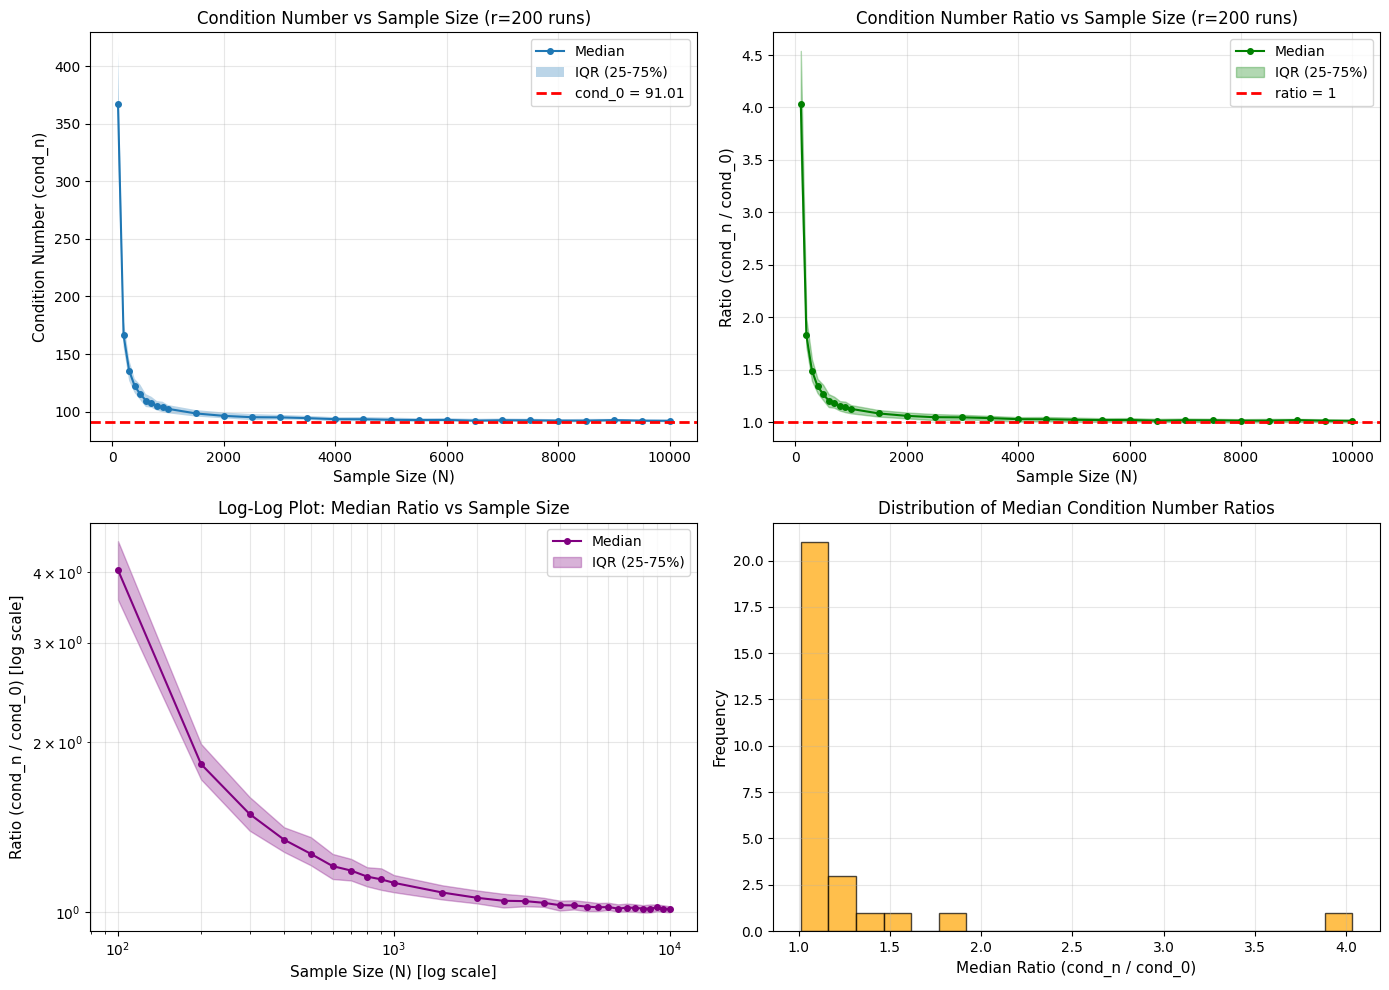

In [9]:
# Plot the condition numbers with median and quartiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: cond_n vs sample size (with quartiles)
axes[0, 0].plot(results_df['sample_size'], results_df['cond_n_median'], 'o-', markersize=4, label='Median')
axes[0, 0].fill_between(results_df['sample_size'], 
                         results_df['cond_n_q25'], 
                         results_df['cond_n_q75'], 
                         alpha=0.3, label='IQR (25-75%)')
axes[0, 0].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 0].set_ylabel('Condition Number (cond_n)', fontsize=11)
axes[0, 0].set_title(f'Condition Number vs Sample Size (r={num_replications} runs)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Ratio (cond_n / cond_0) vs sample size (with quartiles)
axes[0, 1].plot(results_df['sample_size'], results_df['ratio_median'], 'o-', markersize=4, color='green', label='Median')
axes[0, 1].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='green', label='IQR (25-75%)')
axes[0, 1].axhline(y=1, color='r', linestyle='--', label='ratio = 1', linewidth=2)
axes[0, 1].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 1].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0, 1].set_title(f'Condition Number Ratio vs Sample Size (r={num_replications} runs)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Log-log plot (for power law detection)
axes[1, 0].loglog(results_df['sample_size'], results_df['ratio_median'], 'o-', markersize=4, color='purple', label='Median')
axes[1, 0].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='purple', label='IQR (25-75%)')
axes[1, 0].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1, 0].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1, 0].set_title('Log-Log Plot: Median Ratio vs Sample Size', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# Plot 4: Distribution of median ratios
axes[1, 1].hist(results_df['ratio_median'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Median Ratio (cond_n / cond_0)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Median Condition Number Ratios', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Power Law Analysis

In [10]:
# Fit a power law: ratio_median = a * N^b
# Taking log: log(ratio_median) = log(a) + b * log(N)

from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.power(x, b)

# Fit the power law using median values
params, covariance = curve_fit(
    power_law,
    results_df['sample_size'],
    results_df['ratio_median'],
    p0=[1, -0.5]  # Initial guess: ratio decreases with sample size
)

a_fit, b_fit = params
print(f"\nPower Law Fit (using median across {num_replications} runs):")
print(f"  ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"\nParameter uncertainties:")
print(f"  a: {np.sqrt(covariance[0, 0]):.4f}")
print(f"  b: {np.sqrt(covariance[1, 1]):.4f}")


Power Law Fit (using median across 200 runs):
  ratio_median = 9.8235 * N^-0.2837

Parameter uncertainties:
  a: 2.6511
  b: 0.0401


In [11]:
# Compute R-squared to assess fit quality
fitted_values = power_law(results_df['sample_size'], a_fit, b_fit)
residuals = results_df['ratio_median'] - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((results_df['ratio_median'] - np.mean(results_df['ratio_median']))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"  R-squared: {r_squared:.4f}")
print(f"  RMSE: {np.sqrt(np.mean(residuals**2)):.4f}")


Goodness of Fit:
  R-squared: 0.5826
  RMSE: 0.3677


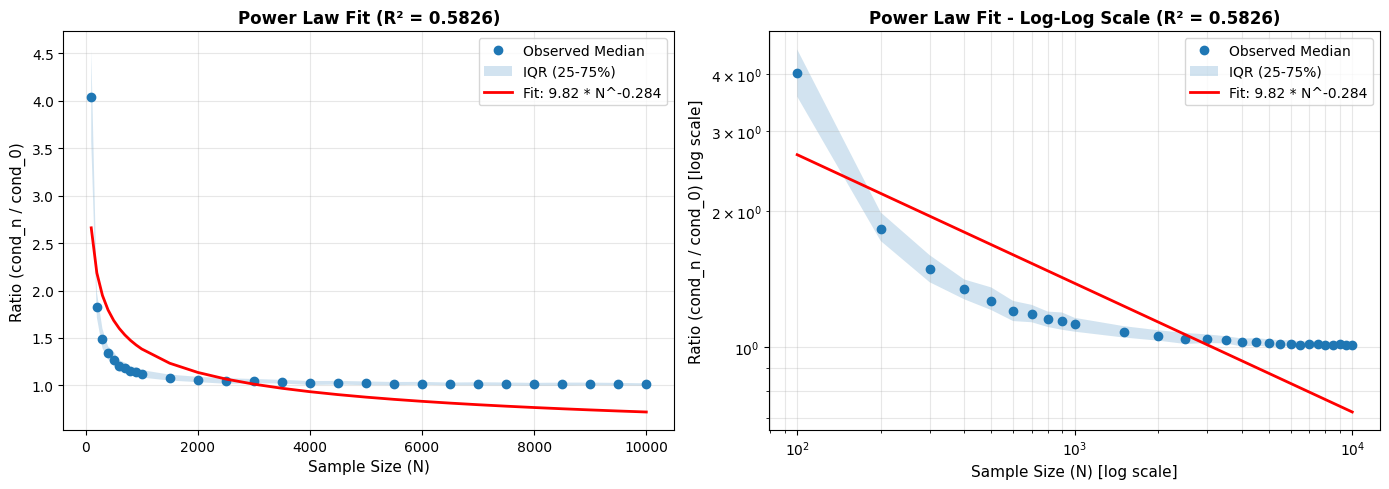

In [12]:
# Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(results_df['sample_size'], results_df['ratio_median'], 'o', label='Observed Median', markersize=6)
axes[0].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[0].plot(results_df['sample_size'], fitted_values, '-', 
             label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0].set_title(f'Power Law Fit (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-log scale
axes[1].loglog(results_df['sample_size'], results_df['ratio_median'], 'o', label='Observed Median', markersize=6)
axes[1].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[1].loglog(results_df['sample_size'], fitted_values, '-', 
               label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[1].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1].set_title(f'Power Law Fit - Log-Log Scale (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 6. Statistical Tests for Power Law

In [13]:
# Linear regression on log-transformed data (using median values)
log_N = np.log(results_df['sample_size'])
log_ratio_median = np.log(results_df['ratio_median'])

# Perform linear regression
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(log_N, log_ratio_median)

print("="*60)
print("LINEAR REGRESSION ON LOG-TRANSFORMED DATA")
print("="*60)
print(f"Using median ratios across {num_replications} replications\n")
print(f"  log(ratio_median) = {intercept:.4f} + {slope:.4f} * log(N)")
print(f"  Which implies: ratio_median = {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"\n  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Standard error: {std_err:.4f}")

if p_value < 0.001:
    print(f"\n✓ The relationship is highly significant (p < 0.001)")
elif p_value < 0.05:
    print(f"\n✓ The relationship is significant (p < 0.05)")
else:
    print(f"\n✗ The relationship is not significant (p >= 0.05)")

LINEAR REGRESSION ON LOG-TRANSFORMED DATA
Using median ratios across 200 replications

  log(ratio_median) = 1.4107 + -0.1646 * log(N)
  Which implies: ratio_median = 4.0986 * N^-0.1646

  R-squared: 0.6066
  p-value: 0.000001
  Standard error: 0.0260

✓ The relationship is highly significant (p < 0.001)


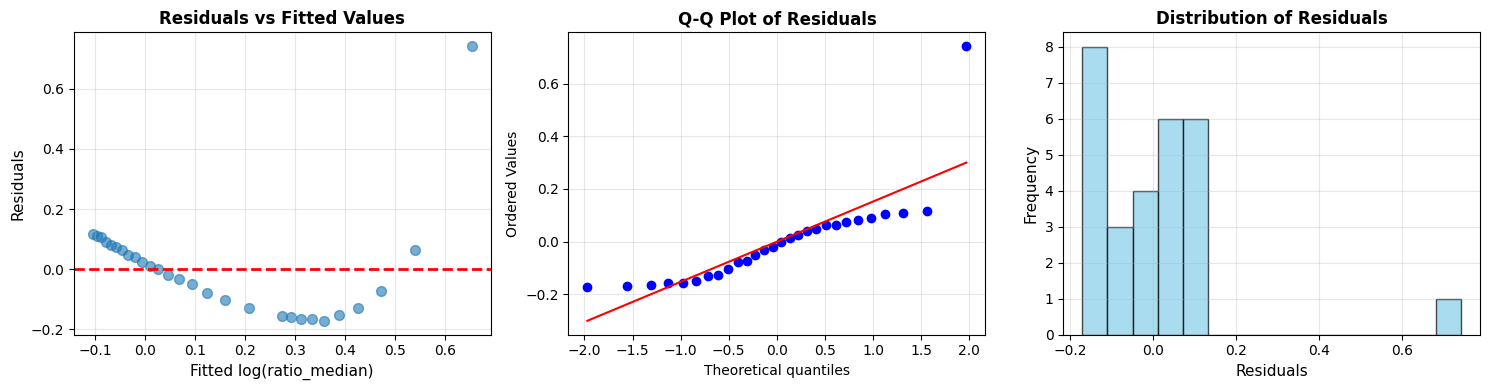

In [14]:
# Residual analysis
log_fitted = intercept + slope * log_N
log_residuals = log_ratio_median - log_fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs fitted
axes[0].scatter(log_fitted, log_residuals, alpha=0.6, s=50)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted log(ratio_median)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(log_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Histogram of residuals
axes[2].hist(log_residuals, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[2].set_xlabel('Residuals', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [15]:
print("="*60)
print("SUMMARY OF RESULTS")
print("="*60)
print(f"\nTrue covariance condition number (cond_0): {cond_0:.4f}")
print(f"\nExperimental Design:")
print(f"  Number of sample sizes tested: {len(sample_sizes)}")
print(f"  Sample size range: {min(sample_sizes)} to {max(sample_sizes)}")
print(f"  Replications per sample size: {num_replications}")
print(f"  Total experiments: {len(sample_sizes) * num_replications}")
print(f"\nCondition number statistics (median across replications):")
print(f"  Min: {results_df['cond_n_median'].min():.4f}")
print(f"  Max: {results_df['cond_n_median'].max():.4f}")
print(f"  Mean: {results_df['cond_n_median'].mean():.4f}")
print(f"  Std: {results_df['cond_n_median'].std():.4f}")
print(f"\nRatio statistics (median cond_n / cond_0):")
print(f"  Min: {results_df['ratio_median'].min():.4f}")
print(f"  Max: {results_df['ratio_median'].max():.4f}")
print(f"  Mean: {results_df['ratio_median'].mean():.4f}")
print(f"  Std: {results_df['ratio_median'].std():.4f}")
print(f"\nVariability across replications (average IQR):")
print(f"  Avg IQR for cond_n: {(results_df['cond_n_q75'] - results_df['cond_n_q25']).mean():.4f}")
print(f"  Avg IQR for ratio: {(results_df['ratio_q75'] - results_df['ratio_q25']).mean():.4f}")
print(f"\nPower Law Fit Results (on median values):")
print(f"  Formula: ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"  R-squared: {r_squared:.4f}")
print(f"  Exponent (b): {b_fit:.4f} ± {np.sqrt(covariance[1, 1]):.4f}")
print(f"\nLinear Regression on Log-Transformed Data:")
print(f"  Formula: ratio_median ≈ {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")

# Interpretation
print(f"\n" + "="*60)
print("INTERPRETATION")
print("="*60)
if r_squared > 0.9:
    print("✓ The data shows a STRONG power law relationship")
elif r_squared > 0.7:
    print("✓ The data shows a MODERATE power law relationship")
else:
    print("✗ The data shows a WEAK power law relationship")

if b_fit < 0:
    print(f"✓ The ratio DECREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This means sample covariance becomes relatively better conditioned with more data")
else:
    print(f"✗ The ratio INCREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This would mean sample covariance becomes relatively worse conditioned with more data")

# Convergence analysis
if results_df['ratio_median'].iloc[-1] < 1.1 and results_df['ratio_median'].iloc[-1] > 0.9:
    print(f"\n✓ The ratio converges to approximately 1 at large N (N={max(sample_sizes)})")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")
else:
    print(f"\n✗ The ratio does not converge to 1 at N={max(sample_sizes)}")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")

SUMMARY OF RESULTS

True covariance condition number (cond_0): 91.0112

Experimental Design:
  Number of sample sizes tested: 28
  Sample size range: 100 to 10000
  Replications per sample size: 200
  Total experiments: 5600

Condition number statistics (median across replications):
  Min: 92.0927
  Max: 367.1695
  Mean: 111.3909
  Std: 52.7559

Ratio statistics (median cond_n / cond_0):
  Min: 1.0119
  Max: 4.0343
  Mean: 1.2239
  Std: 0.5797

Variability across replications (average IQR):
  Avg IQR for cond_n: 9.4270
  Avg IQR for ratio: 0.1036

Power Law Fit Results (on median values):
  Formula: ratio_median = 9.8235 * N^-0.2837
  R-squared: 0.5826
  Exponent (b): -0.2837 ± 0.0401

Linear Regression on Log-Transformed Data:
  Formula: ratio_median ≈ 4.0986 * N^-0.1646
  R-squared: 0.6066
  p-value: 0.000001

INTERPRETATION
✗ The data shows a WEAK power law relationship
✓ The ratio DECREASES as sample size increases (exponent = -0.2837)
  This means sample covariance becomes relativ

In [16]:
# Save results with all statistics
results_df.to_csv('condition_number_results.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'condition_number_results.csv'")
print("="*60)
print("\nSaved columns:")
print("  - sample_size: Number of samples generated")
print("  - cond_n_median: Median condition number across replications")
print("  - cond_n_q25: 25th percentile of condition numbers")
print("  - cond_n_q75: 75th percentile of condition numbers")
print("  - cond_n_mean: Mean condition number across replications")
print("  - cond_n_std: Standard deviation of condition numbers")
print("  - ratio_median: Median of cond_n/cond_0 (used for power law)")
print("  - ratio_q25: 25th percentile of ratios")
print("  - ratio_q75: 75th percentile of ratios")
print("  - ratio_mean: Mean of ratios")
print("  - ratio_std: Standard deviation of ratios")


Results saved to 'condition_number_results.csv'

Saved columns:
  - sample_size: Number of samples generated
  - cond_n_median: Median condition number across replications
  - cond_n_q25: 25th percentile of condition numbers
  - cond_n_q75: 75th percentile of condition numbers
  - cond_n_mean: Mean condition number across replications
  - cond_n_std: Standard deviation of condition numbers
  - ratio_median: Median of cond_n/cond_0 (used for power law)
  - ratio_q25: 25th percentile of ratios
  - ratio_q75: 75th percentile of ratios
  - ratio_mean: Mean of ratios
  - ratio_std: Standard deviation of ratios
